# Decision Trees

Visualizing the decision trees in this notebook requires the <b>pydotplus</b> package; open up an Anaconda prompt, and enter:

```
conda install pydotplus
```

And then restart this notebook's kernel, if you haven't already.

We'll start illustrating decision trees using an example that doesn't involve cars at all, 

but is a better example of the sorts of problems decision trees are suited for. 

First we'll load some fake data on past hires within a company I made up, 

and see if we can construct a decision tree to predict 

if a candidate will be hired based on their attributes.

In [1]:
import numpy as np       
import pandas as pd
from sklearn import tree

input_file = "http://media.sundog-soft.com/SelfDriving/PastHires.csv"
df = pd.read_csv(input_file, header = 0)
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


scikit-learn needs everything to be numerical for decision trees to work. 

So, we'll map Y,N to 1,0 and levels of education to some scale of 0-2. 

In the real world, you'd need to think about how to deal with unexpected or missing data! 

By using map(), we know we'll get NaN for unexpected values.

In [2]:
# Transforming columns to number

d = {'Y': 1, 'N': 0} # Y is mapped to 1, N is mapped to 0

# convert to number 0 and 1 on columns that have 'Y', 'N' values
df['Hired'] = df['Hired'].map(d) 
df['Employed?'] = df['Employed?'].map(d)
df['Top-tier school'] = df['Top-tier school'].map(d)
df['Interned'] = df['Interned'].map(d)

d = {'BS': 0, 'MS': 1, 'PhD': 2}
df['Level of Education'] = df['Level of Education'].map(d)
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0


Next we need to separate the features from the target column that we're trying to bulid a decision tree for.

In [16]:
df.columns[:-1]

Index(['Years Experience', 'Employed?', 'Previous employers',
       'Level of Education', 'Top-tier school', 'Interned'],
      dtype='object')

In [3]:
# sepertate faetures data from the label data 'Hired'
features = list(df.columns[:-1]) 
features

['Years Experience',
 'Employed?',
 'Previous employers',
 'Level of Education',
 'Top-tier school',
 'Interned']

In [4]:
y = df["Hired"]
X = df[features]

In [13]:
# print 
print(type(X))
X

<class 'pandas.core.frame.DataFrame'>


,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned
0,10,1,4,0,0,0
1,0,0,0,0,1,1
2,7,0,6,0,0,0
3,2,1,1,1,1,0
4,20,0,2,2,1,0
5,0,0,0,2,1,1
6,5,1,2,1,0,1
7,3,0,1,0,0,1
8,15,1,5,0,0,0
9,0,0,0,0,0,0


In [14]:
print(type(y))
y

<class 'pandas.core.series.Series'>


0     1
1     1
2     0
3     1
4     0
5     1
6     1
7     1
8     1
9     0
10    0
11    1
12    1
Name: Hired, dtype: int64

Now actually construct the decision tree:

In [15]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X,y)

... and display it. Note you need to have pydotplus installed for this to work. (!pip install pydotplus)

To read this decision tree, each condition branches left for "true" and right for "false". 

When you end up at a value, the value array represents how many samples exist in each "target value" (the unique labels in y data). 

So value = [0. 5.] mean there are 0 "no hires" and 5 "hires" by the tim we get to that point. 

value = [3. 0.] means 3 no-hires and 0 hires.

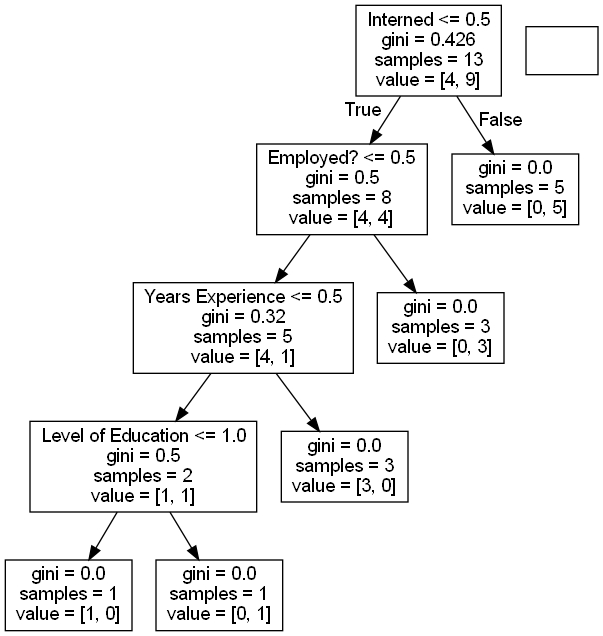

In [17]:
from IPython.display import Image  
from io import StringIO  
import pydotplus

dot_data = StringIO()  
tree.export_graphviz(clf, out_file=dot_data,  
                         feature_names=features)  
                         
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
Image(graph.create_png())  

In [ ]:
# if Interned is > 0.5 (already did do an intern ship) --> likely gonna get hired

# -------------------------------------------------------
# in this case: 
# "False" branch is "intern > 0.5" 
# samples = 5: samples having intern > 0.5 
# [0, 5] means labels: ["not hired", "hired"] according to the y data.
# there are 0 samples (rows/people): labeled 0 (not hired)
# there are 5 samples (rows/people): labeled 1 (hired)
# --> there are total of 5 peoples have interned and all of them get hired

# "True"  branch is "intern <= 0.5"  
# samples = 8: samples having intern <= 0.5 
# [4, 4] means labels: ["not hired", "hired"] according to the y data.
# there are 4 samples (rows/people): labeled 0 (not hired)  
# there are 4 samples (rows/people): labeled 1 (hired)
# --> even though in total 8 people there are 4 people have not interned yet but the results are still get hired.

## Ensemble learning: using a random forest

We'll use a random forest of 10 decision trees to predict employment of specific candidate profiles:

In [20]:
from sklearn.ensemble import RandomForestClassifier

# this is a way to try to prevent overfitting, by introducing some randomization into how each tree is built
# we'll going to build a forest of 10 randomly generated decision trees 
#  
clf = RandomForestClassifier(n_estimators=10)
clf = clf.fit(X, y)

In [21]:
# Predict employment of an employed 10-year veteran --------------

# [ 'Years Experience','Employed?','Previous employers', 
#   'Level of Education','Top-tier school','Interned' ]
inputs = [[10, 1, 4, 0, 0, 0]]
print (clf.predict(inputs)) # desired output: 1 --> hired

#...and an unemployed 10-year veteran ----------------------------
inputs = [[10, 0, 4, 0, 0, 0]] # desired output: 0 --> not hire
print (clf.predict(inputs))

[1]
[0]


c:\ProgramData\Anaconda3\envs\mywork\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\Anaconda3\envs\mywork\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Now, let's see if a DECISION TREE works out for the CLASSIFICATION problem that

we introduced in the Logistic Regression sample: 

predicting if a car should travel fast or slow based on the size and distance of an upcoming bump in the road. 

We'll start by fabricating our data set in the exact same way as before:

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.datasets import make_blobs

n_samples = 10000

# To generate our fabricated data set, we'll create two blobs of
# randomly distributed data at two corners of the graph...
centers = [(0.9, 0.05), (0.05, 0.94)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=0.4,
                  centers=centers, shuffle=False, random_state=42)

# Then filter out only the values that lie within [0,1]:
features = []
labels = []
for feature, label in zip(X, y):
    if (feature[0] >= 0 and feature[0] <= 1.0 and feature[1] >= 0 and feature[1] <= 1.0):
        features.append(feature)
        labels.append(label)

# And convert the results back into numpy arrays:
X = np.array(features)
y = np.array(labels)

Now, let's see what sort of DECISION TREE

 we end with for this data:

In [23]:
clf = tree.DecisionTreeClassifier()
clf.fit(X,y)

dot_data = StringIO()  
tree.export_graphviz(clf, out_file=dot_data,  
                         feature_names=['Distance', 'Bump Size'])  
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
Image(graph.create_png())  

Wow, that's incredibly complicated! 

Given the very simple relationship that's inherent in the data (go slower when you get close to a big bump,) 

this is way over complicated for that kind of datas.

this really looks like OVERFITTING (the nature of DECISION TREE). 

Let's plot the categorizations this decision tree model results in 

so we can visualize just how badly it is overfitting:

C:\Users\Acer\AppData\Local\Temp\ipykernel_4200\3218751400.py:9: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  plt.scatter(X[:,0], X[:,1], c=y.astype(np.float))


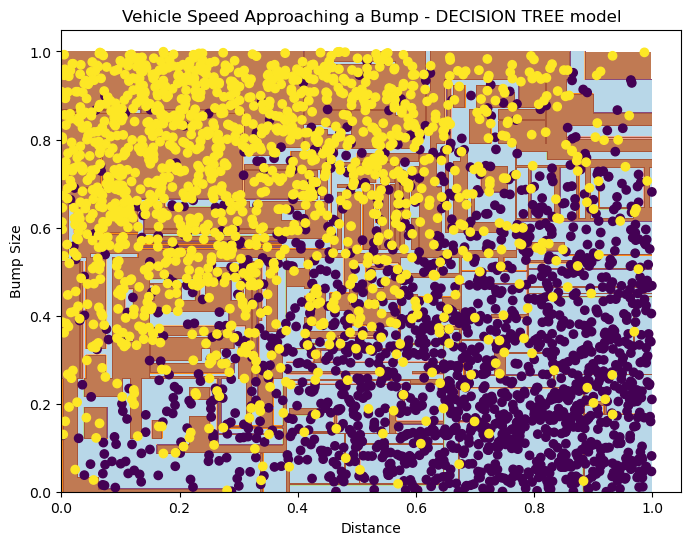

In [26]:
def plotPredictions(clf):
    xx, yy = np.meshgrid(np.arange(0, 1.0, 0.001),
                     np.arange(0, 1.0, 0.001))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    plt.figure(figsize=(8, 6))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    plt.scatter(X[:,0], X[:,1], c=y.astype(np.float))
    plt.xlabel('Distance')
    plt.ylabel('Bump Size')
    plt.title("Vehicle Speed Approaching a Bump - DECISION TREE model")
    plt.show()
    
plotPredictions(clf)

Cross validation should reveal that in fact we don't have a generally useful model here; 

and indeed, the resulting mean accuracy is only 77%, compared to 84% with logistic regression.

In [25]:
from sklearn.model_selection import cross_val_score

fold_scores = cross_val_score(clf, X, y, cv=5)
print (fold_scores)
print (np.mean(fold_scores))

# computing DECISION TREE cross validation scores
# we can see that the model is overfitting and 
# does not preform very well here

[0.77540984 0.76393443 0.76190476 0.74876847 0.7635468 ]
0.7627128590271608


RANDOM FORESTS are meant to prevent overfitting, 

so let's try that with our data. 

It does indeed result in better accuracy as measured by 5-fold cross-validation, 

but the simpler logistic regression model still out-performs it.

In [27]:
# computing RANDOM FORESTS scores, which solve the overfitting problems of decision tree.
# and the results are way better here
# but it's still not as good as logistic regression which got us 84%

clf = RandomForestClassifier(n_estimators=10)
clf = clf.fit(X, y)

fold_scores = cross_val_score(clf, X, y, cv=5)
print (fold_scores)
print (np.mean(fold_scores))

[0.80655738 0.8        0.80952381 0.79638752 0.79310345]
0.8011144310748607


## Activity

Modify the test data to create an alternate universe where everyone I hire everyone I normally wouldn't have, and vice versa. Compare the resulting decision tree to the one from the original data.